# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal de clasificación con **Keras 3**.

En este ejercicio vas a aplicar la misma receta sobre un dataset diferente:

> **Olivetti Faces**

El dataset contiene imágenes de rostros en escala de grises. El objetivo será identificar a cuál persona pertenece cada imagen.

No necesitas diseñar un pipeline de datos nuevo. La carga, división y visualización están resueltas.

Tu trabajo se concentra en completar las etapas principales de Keras:

```text
Datos
  ↓
Modelo
  ↓
Loss + Optimizer
  ↓
Entrenamiento
  ↓
Evaluación
  ↓
Predicción
```

---

## ¿Qué debes completar?

Las celdas marcadas con `# TODO` contienen espacios que debes completar.

El resto del código está preparado para que puedas concentrarte en los conceptos vistos en clase.


---
## 0. Importar librerías

Usaremos:

- **Keras 3** para construir y entrenar la red.
- **scikit-learn** para cargar Olivetti Faces y dividir los datos.
- **NumPy** para manipular arrays.
- **Matplotlib** para visualizar imágenes.


In [2]:
import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")




I0000 00:00:1790260185.239612   21866 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790260185.245875   21866 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790260185.843993   21866 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790260187.787604   21866 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: Olivetti Faces

Olivetti Faces contiene:

- **400 imágenes**
- imágenes de **64 × 64 píxeles**
- escala de grises
- **40 personas**
- **10 imágenes por persona**

La etiqueta indica la identidad de la persona:

```text
0, 1, 2, ..., 39
```

Cada imagen ya viene representada con valores flotantes aproximadamente en el rango:

$$
[0,1]
$$

Por eso, en este ejercicio **no necesitamos normalizar dividiendo por 255**.


In [3]:
faces = fetch_olivetti_faces(
    shuffle=True,
    random_state=SEED
)

X = faces.images
y = faces.target

print("X:", X.shape)
print("y:", y.shape)
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Número de clases:", len(np.unique(y)))


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/sal1n4x/scikit_learn_data
X: (400, 64, 64)
y: (400,)
Valor mínimo: 0.0
Valor máximo: 1.0
Número de clases: 40


## 1.1 Dividir entrenamiento y prueba

Como solo tenemos 10 imágenes por persona, debemos asegurarnos de que todas las identidades aparezcan tanto en entrenamiento como en prueba.

Usaremos una división **estratificada**:

```text
80% entrenamiento
20% prueba
```

La opción:

```python
stratify=y
```

mantiene la proporción de cada clase en ambos conjuntos.

Esta parte está resuelta.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nPersonas en train:", len(np.unique(y_train)))
print("Personas en test :", len(np.unique(y_test)))


X_train: (320, 64, 64)
X_test : (80, 64, 64)
y_train: (320,)
y_test : (80,)

Personas en train: 40
Personas en test : 40


### Pregunta 1

Cada imagen tiene tamaño:

$$
64 \times 64
$$

Cuando apliquemos `Flatten()`, ¿cuántos valores tendrá cada ejemplo?

**Respuesta:** Cada ejemplo tendrá 4096 valores, porque 64 x 64 = 4096.




---
## 1.2 Visualizar algunas imágenes

Esta parte está resuelta.

Observa que varias fotografías corresponden a la misma persona con pequeñas variaciones de expresión, iluminación y orientación.


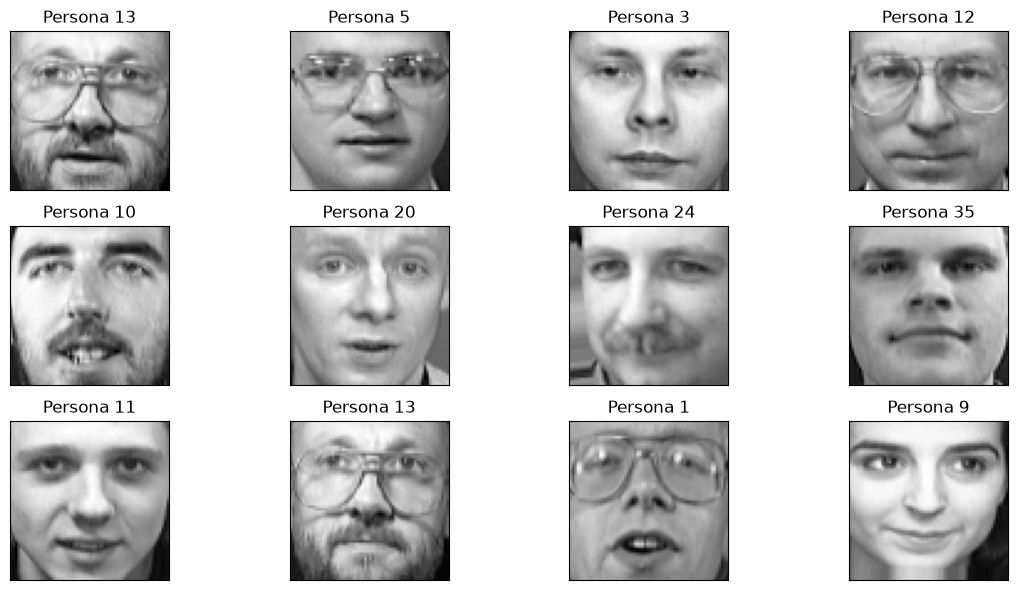

In [5]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Persona {y_train[i]}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Usaremos una arquitectura fully-connected similar a la vista en clase:

```text
Imagen 64×64
     ↓
Flatten
     ↓
4096 valores
     ↓
Dense(64)
     ↓
ReLU
     ↓
Dense(40)
     ↓
Logits
```

La última capa debe tener una salida por cada clase.

> **Importante:** no añadas `Softmax` al final. Trabajaremos directamente con **logits**.


In [6]:
model = keras.Sequential([

    keras.Input(shape=(64, 64)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(40)
])

model.summary()

E0000 00:00:1790260192.616296   21866 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,808 (1.01 MB)

 Trainable params: 264,808 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
assert isinstance(model, keras.Model)

# Dense(64): 4096*64 + 64
# Dense(40): 64*40 + 40
expected_params = (4096 * 64 + 64) + (64 * 40 + 40)

assert model.count_params() == expected_params, (
    f"Se esperaban {expected_params:,} parámetros, "
    f"pero el modelo tiene {model.count_params():,}."
)

print(f"Parámetros entrenables: {model.count_params():,}")


Parámetros entrenables: 264,808


### Pregunta 2

¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:** Necesitamos Flatten() para convertir la imagen de 64×64 en un vector de 4096 valores. La capa Dense recibe los datos como un vector de entrada, por lo que Flatten() permite conectar cada píxel con las neuronas de la capa densa.


### Pregunta 3

¿Por qué la última capa tiene **40 neuronas**?

**Respuesta:** La última capa tiene 40 neuronas porque el dataset contiene 40 personas diferentes. Cada neurona representa una de las 40 posibles clases o personas que el modelo puede predecir.


### Pregunta 4

¿Qué función cumple `ReLU` en la capa oculta?

**Respuesta:** ReLU introduce no linealidad en la red y permite que el modelo aprenda relaciones más complejas entre los píxeles de las imágenes. Su funcionamiento básico es convertir los valores negativos en 0 y mantener los valores positivos.




---
# 3. Configurar el entrenamiento

Las etiquetas son números enteros entre:

```text
0 y 39
```

Por eso usaremos:

```python
SparseCategoricalCrossentropy
```

Además:

- el modelo produce **logits**,
- usaremos **Adam**,
- mediremos **accuracy**.

Completa `model.compile()`.


In [8]:
lr_rate = 0.01


model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=lr_rate
    ),

    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=["accuracy"]
    
)

### Pregunta 5

¿Por qué usamos:

```python
from_logits=True
```

en la función de pérdida?

**Respuesta:** Usamos from_logits=True porque la última capa del modelo no utiliza Softmax, por lo que produce valores llamados logits. Esta opción permite que SparseCategoricalCrossentropy procese directamente esos logits y realice internamente el cálculo necesario para obtener la pérdida.




---
# 4. Entrenar el modelo

Usaremos:

```python
epochs = 30
batch_size = 32
```

El dataset es pequeño, por lo que el entrenamiento debería ser rápido.

Keras realizará internamente:

```text
Forward pass
      ↓
Calcular loss
      ↓
Backpropagation
      ↓
Actualizar parámetros con Adam
```

Completa la llamada a `fit()`.


In [9]:
epochs = 30
batch_size = 32

history = model.fit(

    X_train,
    y_train,

    epochs=epochs,
    batch_size=batch_size,

    validation_data=(X_test, y_test),

    shuffle=True
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0188 - loss: 11.0251 - val_accuracy: 0.0250 - val_loss: 3.6893
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0125 - loss: 3.6901 - val_accuracy: 0.0250 - val_loss: 3.6897
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0125 - loss: 3.6904 - val_accuracy: 0.0250 - val_loss: 3.6897
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0125 - loss: 3.6905 - val_accuracy: 0.0250 - val_loss: 3.6897
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0125 - loss: 3.6905 - val_accuracy: 0.0250 - val_loss: 3.6896
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0156 - loss: 3.6904 - val_accuracy: 0.0250 - val_loss: 3.6896
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0156 - loss: 3.6903 - val_accuracy: 0.0250 - val_loss: 3.6895
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0156 - loss: 3.6903 - val_accuracy: 0.0250 - val_los

In [10]:
hidden = model.layers[1](model.layers[0](X_train[:5]))

print("Máximo:", np.max(hidden.numpy()))
print("Media:", np.mean(hidden.numpy()))
print("Positivos:", np.sum(hidden.numpy() > 0))

Máximo: 0.0
Media: 0.0
Positivos: 0


### Pregunta 6

¿Qué representa una **epoch**?

**Respuesta:** Una epoch representa una pasada completa por todas las imágenes del conjunto de entrenamiento. En este ejercicio, epochs=30 significa que el modelo tendrá la oportunidad de aprender de las imágenes de entrenamiento 30 veces.


### Pregunta 7

¿Qué significa `batch_size=32`?

**Respuesta:** Significa que el modelo procesa 32 imágenes a la vez antes de realizar una actualización de sus parámetros. Como tenemos 320 imágenes de entrenamiento, cada epoch tendrá aproximadamente 10 batches.




---
## 4.1 Visualizar el entrenamiento

Esta parte está resuelta.

El dataset tiene muy pocos ejemplos comparado con el número de parámetros de la red.

Observa cuidadosamente la diferencia entre entrenamiento y validación.


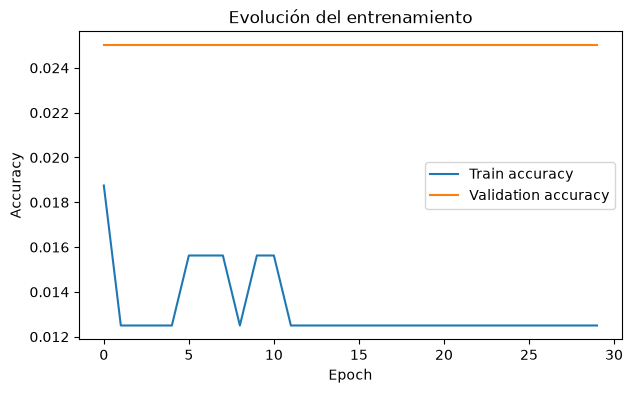

In [11]:
plt.figure(figsize=(7, 4))

plt.plot(
    history.history["accuracy"],
    label="Train accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()

plt.show()


### Pregunta 8

Observando la gráfica:

- ¿El accuracy de entrenamiento sigue aumentando?
- ¿El accuracy de validación se comporta igual?
- ¿Observas evidencia de **overfitting**?

**Respuesta:**
- El accuracy de entrenamiento no sigue aumentando de manera significativa. Después de las primeras epochs permanece aproximadamente entre 1 % y 2 %.
- El accuracy de validación también permanece prácticamente constante, alrededor del 2.5 %, sin mostrar una mejora durante el entrenamiento.
- No se observa el comportamiento típico de overfitting. En un caso de overfitting esperaríamos que el accuracy de entrenamiento aumentara mientras que el accuracy de validación empeorara o se mantuviera considerablemente más bajo. Lo que pasó es que el modelo no aprendió nada, porque 2.5% es lo mismo que adivinar al azar entre 40 personas. Al revisar la capa oculta todas las neuronas dan 0, entonces ReLU no deja pasar nada y los pesos ya no se actualizan. Creemos que puede ser porque el learning rate de 0.01 es alto para este modelo.



---
# 5. Evaluar el modelo

Ahora evaluaremos el modelo sobre imágenes que no fueron utilizadas para actualizar sus parámetros.

Completa `evaluate()`.


In [12]:
test_loss, test_accuracy = model.evaluate(

    X_test,
    y_test,

    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss}")
print(f"Test accuracy : {test_accuracy}")
print(f"Accuracy (%)  : {test_accuracy * 100}%")

Test loss     : 3.6889126300811768
Test accuracy : 0.02500000037252903
Accuracy (%)  : 2.500000037252903%


### Pregunta 9

Tenemos **40 clases**, pero solamente **320 imágenes de entrenamiento**.

¿Crees que la cantidad de datos es grande o pequeña para una red con cientos de miles de parámetros?

**Respuesta:** La cantidad de datos es pequeña para una red con cientos de miles de parámetros. La red tiene 264,808 parámetros y solo hay 320 imágenes de entrenamiento, 8 por cada persona. Con tan pocos ejemplos la red puede terminar memorizando las fotos en vez de aprender a reconocer a cada persona.




---
# 6. Logits y Softmax

La salida de nuestro modelo tiene forma:

```text
(batch_size, 40)
```

Cada uno de los 40 valores corresponde al **logit** asociado a una persona.

Los logits no son probabilidades.

Para convertirlos en probabilidades usamos:

```python
keras.ops.softmax(...)
```


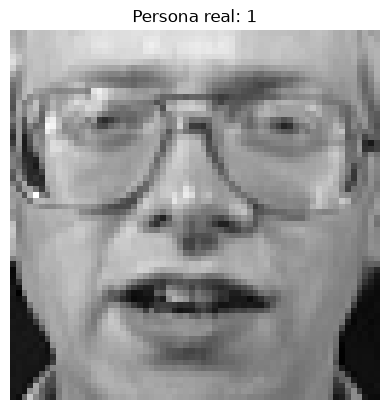

Shape de logits: (1, 40)

Primeros 10 logits:
[0.0341358  0.03345293 0.03781349 0.02069901 0.03533985 0.03434537
 0.01364834 0.03428139 0.03450484 0.0374339 ]


In [13]:
index = 0

image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Persona real: {true_class}")
plt.axis("off")
plt.show()

# Añadimos dimensión de batch:
# (64,64) -> (1,64,64)
image_batch = np.expand_dims(image, axis=0)

# Forward pass.
logits = model(
    image_batch,
    training=False
)

print("Shape de logits:", logits.shape)
print("\nPrimeros 10 logits:")
print(
    keras.ops.convert_to_numpy(logits)[0, :10]
)


In [ ]:
probabilities = keras.ops.softmax(logits)


prediction = keras.ops.argmax(
    probabilities,
    axis=1
)

prediction = int(
    keras.ops.convert_to_numpy(prediction)[0]
)

print()
print("Persona real     :", true_class)
print("Persona predicha :", prediction)


Persona real     : 1
Persona predicha : 10


In [15]:
# Revisamos las cinco clases con mayor probabilidad.

probabilities_np = keras.ops.convert_to_numpy(
    probabilities
)[0]

top5 = np.argsort(
    probabilities_np
)[-5:][::-1]

print("Top 5 predicciones:\n")

for class_id in top5:
    print(
        f"Persona {class_id:2d}: "
        f"{probabilities_np[class_id]:.4f}"
    )

print(
    "\nSuma de probabilidades:",
    probabilities_np.sum()
)


Top 5 predicciones:

Persona 10: 0.0252
Persona 23: 0.0252
Persona 33: 0.0251
Persona  2: 0.0251
Persona  9: 0.0251

Suma de probabilidades: 1.0


### Pregunta 10

¿Por qué la suma de las 40 probabilidades obtenidas con `Softmax` debe ser aproximadamente `1`?

**Respuesta:** Porque Softmax transforma los 40 logits en probabilidades normalizadas. Cada valor representa la probabilidad de que la imagen pertenezca a una determinada persona y todas las probabilidades juntas deben representar el 100% de las posibilidades. Por eso su suma es aproximadamente 1.




---
# 7. Visualizar varias predicciones

Esta parte está resuelta.

Observa especialmente los casos en los que el modelo se equivoca.


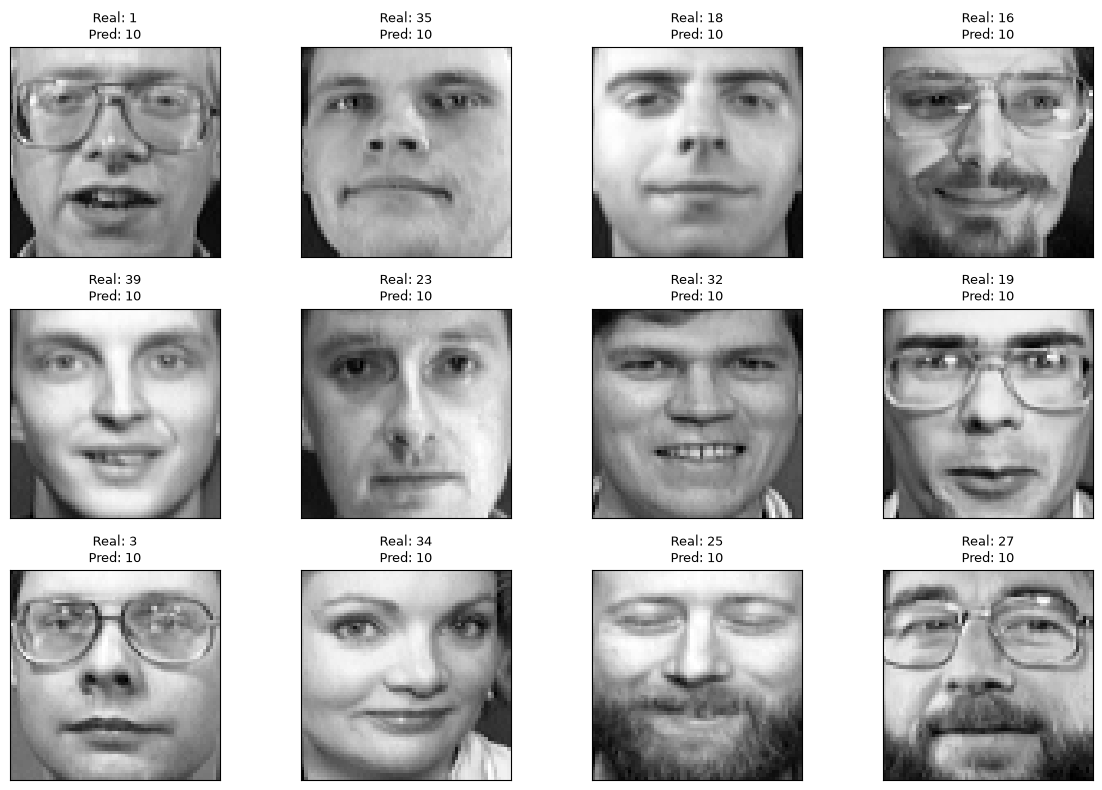

In [16]:
n = 12

logits_batch = model(
    X_test[:n],
    training=False
)

predictions = keras.ops.argmax(
    logits_batch,
    axis=1
)

predictions = keras.ops.convert_to_numpy(
    predictions
)

plt.figure(figsize=(12, 8))

for i in range(n):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    real = y_test[i]
    pred = predictions[i]

    plt.title(
        f"Real: {real}\nPred: {pred}",
        fontsize=9
    )

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 8. Reflexión final

Responde brevemente.

### 1. ¿Cuál fue el accuracy final del modelo?

**Respuesta:** 2.50%, que es lo mismo que adivinar al azar entre las 40 personas.


### 2. ¿Observaste overfitting? ¿Qué evidencia utilizaste?

**Respuesta:** No. No se observa evidencia clara de overfitting. El accuracy de entrenamiento tampoco aumenta considerablemente, sino que permanece aproximadamente entre 1 % y 2 %, mientras que el accuracy de validación se mantiene alrededor del 2.50 %. Lo que pasó fue que el modelo no aprendió, la loss se quedó casi en el mismo valor desde la segunda epoch.


### 3. ¿Qué ocurre cuando tenemos muchos parámetros pero pocos ejemplos de entrenamiento?

**Respuesta:** El modelo tiene una gran capacidad para aprender los datos de entrenamiento, pero al haber pocos ejemplos puede memorizar parte de ellos en lugar de aprender patrones generales


### 4. Después de `Flatten()`, una cara de 64×64 se convierte en un vector de 4096 números.

¿Qué información sobre la estructura de la imagen deja de representar explícitamente esta transformación?

**Respuesta:** Flatten() elimina la representación explícita de la estructura espacial de la imagen. Después de convertir la imagen en un vector de 4096 números, la red ya no recibe directamente información sobre qué píxeles están cerca de otros píxeles


### 5. ¿Crees que una arquitectura diseñada específicamente para imágenes podría aprovechar mejor la información espacial?

**Respuesta:** Sí. Una arquitectura para imágenes puede aprovechar mejor la estructura espacial de las imágenes porque utiliza operaciones de convolución capaces de detectar patrones locales como bordes, formas y otras características.


---

## Para pensar

Nuestra red recibe:

```text
64 × 64
   ↓
Flatten
   ↓
4096 números
   ↓
Dense
```

Pero una imagen tiene una estructura espacial:

- píxeles cercanos están relacionados,
- existen bordes,
- existen formas,
- existen patrones locales.

Una red fully-connected no incorpora explícitamente esa estructura.

Esto motiva una arquitectura diseñada específicamente para imágenes:

> **Convolutional Neural Networks (CNNs)**


---
# Resumen

En este ejercicio aplicaste nuevamente la receta básica de entrenamiento de una red neuronal:

```text
Dataset
   ↓
Train / Test split
   ↓
Sequential
   ↓
Flatten
   ↓
Dense + ReLU
   ↓
Dense(40)
   ↓
Cross-Entropy
   ↓
Adam
   ↓
fit()
   ↓
evaluate()
```

Los componentes de Keras son los mismos que usamos en clase.

Lo que cambió fue:

- el dataset,
- el tamaño de las imágenes,
- el número de clases,
- y la dificultad del problema.
